# Headline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download

In [ ]:
!pip install boruta
!pip install bayesian-optimization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.7 MB/s eta 0:00:00


## Import

In [ ]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# feature selection methods imports
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ks_2samp
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy
from sklearn.feature_selection import mutual_info_regression

# Regime Switching imports
from sklearn.mixture import GaussianMixture

# SMOTE engine
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# model & tuning imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from bayes_opt import BayesianOptimization

# validation imports
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve

# Data( Cleaned) Input

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/COURSES/Extension Projects/Code/Data Sources/DIG_data_set_for_regimes.csv')

data

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,roll_std_20,roll_skew_20,roll_kurt_20,z_score,hurst,garch_volatility,vwap,dist_vwap,force_index,amihud_illiq
0,3.38,3.55,3.34,3.55,2761460,-9.616120e+06,8.714330e+06,-0.165504,16968.270979,1.180446,...,0.025241,0.864960,0.310577,2.673555,0.334259,2.173286,3.458107,0.026573,579906.6,2.208136e-08
1,3.67,3.72,3.59,3.67,2336410,-6.854660e+06,1.147579e+07,0.081603,97388.032267,1.140701,...,0.025637,0.623834,-0.172504,2.649854,0.341582,2.807469,3.468953,0.057956,280369.2,1.422869e-08
2,3.67,3.76,3.63,3.72,1204680,-6.315488e+06,1.381220e+07,0.105778,123528.199086,1.168459,...,0.025612,0.539774,-0.235840,2.331197,0.357664,2.801939,3.475270,0.070420,60234.0,1.123286e-08
3,3.72,3.76,3.59,3.59,1570480,-5.852150e+06,1.501688e+07,0.128934,114486.170645,0.431650,...,0.026388,0.413794,-0.224038,1.492845,0.373076,2.674291,3.481088,0.031287,-204162.4,2.265006e-08
4,3.59,3.67,3.55,3.59,746480,-7.422630e+06,1.344640e+07,0.038115,68964.946267,-0.216494,...,0.026388,0.413794,-0.224038,1.333182,0.389223,2.858598,3.483029,0.030712,0.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,13.54,14.10,13.45,13.84,15060300,-6.929636e+08,1.772220e+09,-0.260383,131040.816306,-0.606725,...,0.023348,-1.697352,4.326719,1.282793,0.583102,2.353832,21.121610,-0.344747,3162663.0,1.015232e-09
2265,13.93,13.97,13.67,13.71,6530700,-6.899516e+08,1.787280e+09,-0.191036,564129.699691,-0.194219,...,0.022613,-1.687347,4.493780,0.968153,0.586032,2.299141,21.118543,-0.350808,-848991.0,1.445091e-09
2266,13.80,13.80,13.50,13.67,8952900,-6.947408e+08,1.780750e+09,-0.295668,362255.314020,0.206716,...,0.022626,-1.662990,4.421019,0.859906,0.589697,2.224058,21.114271,-0.352571,-358116.0,3.263571e-10
2267,13.67,13.93,13.50,13.76,12181700,-6.935470e+08,1.771797e+09,-0.295142,259345.126303,-0.569648,...,0.021814,-2.001291,6.211229,0.965136,0.591952,2.123972,21.108523,-0.348131,1096353.0,5.386918e-10


## data train-test split

In [ ]:
df = data.copy()
df[['ret']] = df[['ret']].shift(-1)
df.dropna(inplace=True)

print(f"input data shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")

input data shape: (2268, 103)
columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 't

# Feature Engineering

## Causality Test

In [ ]:
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import grangercausalitytests

# --- PART 1: The Granger Function ---
def get_best_granger_features(data, target_col, features, max_lag=5):
    """
    Tests Granger Causality for each feature against the target.
    Returns:
        1. best_lags: Dict {feature_name: optimal_lag}
        2. results_df: DataFrame with detailed stats
    """
    best_lags = {}
    detailed_results = []

    print(f"Starting Granger Causality Test on {len(features)} features...")

    for feature in features:
        # Skip if the feature is the target itself
        if feature == target_col:
            continue

        # Create a temp df with just the two columns we care about
        # Order matters for statsmodels: [Target, Predictor]
        # We are testing: Does 'feature' Granger-cause 'target_col'?
        test_df = data[[target_col, feature]].dropna()

        # Safety check: Ensure columns are numeric and have enough variance
        if not np.issubdtype(test_df[feature].dtype, np.number) or test_df[feature].nunique() <= 1:
            continue

        try:
            # verbose=False prevents it from spamming your console
            test_output = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        except Exception as e:
            # Common errors: Singular matrix (collinearity), constant data
            # print(f"Skipping {feature}: {e}")
            continue

        # Track the best lag for this specific feature
        best_f_score = -1
        best_lag_for_feature = -1
        is_significant = False

        for lag, result in test_output.items():
            # result[0] contains the test stats
            # 'ssr_ftest' is the F-test for the Granger causality
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]

            # Save details for review
            detailed_results.append({
                'Feature': feature,
                'Lag': lag,
                'F_Statistic': f_stat,
                'P_Value': p_val
            })

            # Check for significance (p < 0.05) and maximizing F-stat
            if p_val < 0.05:
                is_significant = True
                if f_stat > best_f_score:
                    best_f_score = f_stat
                    best_lag_for_feature = lag

        # Only keep the feature if it had at least one significant lag
        if is_significant:
            best_lags[feature] = best_lag_for_feature

    results_df = pd.DataFrame(detailed_results)
    return best_lags, results_df

def engineer_asymmetry(df):
    df = df.copy()

    # 1. Semi-Variance (Downside vs Upside Volatility)
    # Isolates the volatility of only the positive days vs only the negative days
    df['ret_pos'] = df['ret'].clip(lower=0)
    df['ret_neg'] = df['ret'].clip(upper=0)

    df['volatility_upside'] = df['ret_pos'].rolling(window=window).std()
    df['volatility_downside'] = df['ret_neg'].rolling(window=window).std()

    # The Asymmetry Ratio: Spikes when downside volatility dominates, drops when market stabilizes
    df['vol_asymmetry_ratio'] = df['volatility_upside'] / (df['volatility_downside'] + 1e-6)

    # 2. Cumulative Drawdown (The "Buy the Dip" detector)
    # Using a cumulative product of returns as a price proxy if raw 'close' isn't available
    df['price_proxy'] = (1 + df['ret']).cumprod()
    df['roll_max_20'] = df['price_proxy'].rolling(window=window).max()

    # Measures how far we are from the recent local high (always 0 or negative)
    df['drawdown_20'] = (df['price_proxy'] - df['roll_max_20']) / (df['roll_max_20'] + 1e-6)

    # 3. Drawdown Velocity (Is the crash accelerating or exhausting?)
    df['drawdown_velocity'] = df['drawdown_20'].diff()

    # Clean up temporary columns
    df.drop(columns=['ret_pos', 'ret_neg', 'price_proxy', 'roll_max_20'], inplace=True)

    return df

## Relative Strength & Cross-Asset Correlation

In [ ]:
import pandas as pd
import numpy as np

def engineer_cross_asset(df, asset_col='Close', benchmark_col='spy_close', window=20):
    df = df.copy()

    # 1. Relative Strength Ratio (Asset Price / Benchmark Price)
    df['relative_strength_ratio'] = df[asset_col] / (df[benchmark_col] + 1e-8)

    # 2. Relative Strength Momentum (Is the outperformance accelerating?)
    df['rs_momentum'] = df['relative_strength_ratio'].pct_change(periods=5)

    # 3. Rolling Beta (Covariance / Variance)
    asset_ret = df[asset_col].pct_change()
    bench_ret = df[benchmark_col].pct_change()

    rolling_cov = asset_ret.rolling(window).cov(bench_ret)
    rolling_var = bench_ret.rolling(window).var()

    df['rolling_beta'] = rolling_cov / (rolling_var + 1e-8)

    return df

## Volatility Term Structure

In [ ]:
def engineer_vol_term_structure(df, target_col='ret', short_window=5, long_window=20):
    df = df.copy()

    # Calculate realized volatility (standard deviation of returns)
    short_vol = df[target_col].rolling(window=short_window).std()
    long_vol = df[target_col].rolling(window=long_window).std()

    # Volatility Term Structure Ratio
    # > 1.0 means short-term panic (backwardation)
    # < 1.0 means normal market conditions (contango)
    df['vol_term_structure'] = short_vol / (long_vol + 1e-8)

    # Volatility Acceleration (Is panic increasing?)
    df['vol_acceleration'] = df['vol_term_structure'].diff()

    return df

## Volume Profile & Order Flow

In [ ]:
def engineer_order_flow(df, window=5):
    df = df.copy()

    # Typical Price
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3.0

    # Rolling VWAP
    rolling_vol_price = (typical_price * df['Volume']).rolling(window=window).sum()
    rolling_vol = df['Volume'].rolling(window=window).sum()

    df[f'vwap_{window}d'] = rolling_vol_price / (rolling_vol + 1e-8)

    # Distance from VWAP (Positive = buyers in profit, Negative = buyers underwater)
    df['vwap_distance'] = (df['Close'] - df[f'vwap_{window}d']) / (df[f'vwap_{window}d'] + 1e-8)

    return df

## Executing

### train-test setting up

In [ ]:
# ==========================================
# PHASE 1: ADVANCED CONTEXT FEATURE CREATION
# (Run this on your full, unsplit 'df')
# ==========================================

# NOTE: Ensure your 'df' still has 'high', 'low', 'close', 'volume', and a merged benchmark like 'spy_close'
'''
df = engineer_cross_asset(df, asset_col='Close', benchmark_col='spy_close', window=20)
'''
df = engineer_vol_term_structure(df, target_col='ret', short_window=5, long_window=20)
df = engineer_order_flow(df, window=5)

# Drop NaNs created by the new 20-day rolling windows
df.dropna(inplace=True)

# (Optional) Now you can drop the raw OHLCV and benchmark columns if you strictly
# want the model to learn from the derived indicators and context features, not raw prices.
'''
cols_to_drop = ['open', 'high', 'low', 'close', 'volume', 'spy_close']
'''
cols_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume']
df_after_engineering = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ==========================================
# PHASE 2: THE TIME BARRIER (SPLITTING)
# ==========================================

# Split BEFORE doing any forward-looking target shifting or Granger scaling
train_df, test_df = train_test_split(df_after_engineering, test_size=0.2, shuffle=False)

### engineering process:

In [ ]:
# ==========================================
# PHASE 3: GRANGER CAUSALITY TEST
# ==========================================

# Define features to test (exclude the current return to avoid testing it against itself)
feature_cols = [c for c in train_df.columns if c != 'ret']

# Run Granger Test on the UNSHIFTED return
best_lags, granger_stats = get_best_granger_features(
    data=train_df,
    target_col='ret',
    features=feature_cols,
    max_lag=5
)

print(f"\nGranger identified {len(best_lags)} significant features.")

# ==========================================
# PHASE 4: SCALING & KINEMATICS (Applying Lags)
# ==========================================

window = 20
warmup_buffer = train_df.tail(window)
full_test_df = pd.concat([warmup_buffer, test_df])

# 1. Apply Volatility-Scaled Lags
for feature, lag in best_lags.items():
    def get_aligned_scaling(df_in, feat, l):
        val_lagged = df_in[feat].shift(l)
        roll_mu = df_in[feat].rolling(window=window).mean().shift(l)
        roll_sigma = df_in[feat].rolling(window=window).std().shift(l)
        return (val_lagged - roll_mu) / (roll_sigma + 1e-6)

    col_name = f"{feature}_lag{lag}_scaled"
    train_df[col_name] = get_aligned_scaling(train_df, feature, lag)
    full_test_df[col_name] = get_aligned_scaling(full_test_df, feature, lag)

# 2. Apply Momentum & Acceleration
for feature, lag in best_lags.items():
    col_name_mom = f"{feature}_lag{lag}_momentum"
    train_df[col_name_mom] = (train_df[feature] - train_df[feature].shift(lag)) / (train_df[feature].shift(lag) + 1e-6)
    full_test_df[col_name_mom] = (full_test_df[feature] - full_test_df[feature].shift(lag)) / (full_test_df[feature].shift(lag) + 1e-6)

    col_name_acc = f"{feature}_lag{lag}_acceleration"
    train_df[col_name_acc] = train_df[col_name_mom].diff()
    full_test_df[col_name_acc] = full_test_df[col_name_mom].diff()

# Remove buffer and clean up
test_df = full_test_df.iloc[window:].copy()
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

Starting Granger Causality Test on 101 features...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


Granger identified 60 significant features.


/tmp/ipykernel_380/2667999755.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[col_name_acc] = train_df[col_name_mom].diff()
/tmp/ipykernel_380/2667999755.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_test_df[col_name_acc] = full_test_df[col_name_mom].diff()
/tmp/ipykernel_380/2667999755.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

### Engineer the Multi-Day:

In [ ]:
# ==========================================
# PHASE 5: ASYMMETRY & TARGET ENGINEERING
# ==========================================

# Apply your asymmetry function
train_df = engineer_asymmetry(train_df)
test_df = engineer_asymmetry(test_df)

# Engineer the Multi-Day Forward Target (5-Day Cumulative Return)
horizon = 3
train_df[f'target_{horizon}d_ret'] = train_df['ret'].rolling(window=horizon).sum().shift(-horizon)
test_df[f'target_{horizon}d_ret'] = test_df['ret'].rolling(window=horizon).sum().shift(-horizon)

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

train_df.head()

,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,volume_sma_em,volume_vpt,volume_vwap,volume_mfi,volume_nvi,...,vwap_5d_lag5_momentum,vwap_5d_lag5_acceleration,vwap_distance_lag2_momentum,vwap_distance_lag2_acceleration,volatility_upside,volatility_downside,vol_asymmetry_ratio,drawdown_20,drawdown_velocity,target_3d_ret
64,-1.467350e+06,31015280.0,0.425636,16727.583492,-0.899806,-0.118419,569958.729431,4.022340,63.265096,728.725675,...,-0.029380,0.002561,-1.707051,-0.638731,0.059595,0.052403,1.137229,-0.166416,0.000000,-0.13
65,-8.016304e+05,31681000.0,0.456512,22897.185850,1.757496,-0.146604,585127.033228,4.044966,60.347958,728.725675,...,-0.028292,0.001087,19.312147,21.019199,0.060461,0.056092,1.077869,-0.274782,-0.108366,-0.14
66,-5.547104e+05,31927920.0,0.453176,19626.159300,0.728981,-0.366528,585127.033228,4.047912,59.974824,728.725675,...,-0.014280,0.014012,-1.548912,-20.861059,0.060461,0.055391,1.091511,-0.274782,0.000000,-0.32
67,-6.333604e+05,31849270.0,0.451508,15361.779400,-3.305785,-0.658605,582596.216396,4.053264,54.092257,705.276581,...,-0.005209,0.009071,-1.541515,0.007397,0.061239,0.055391,1.105565,-0.274782,0.000000,-0.36
68,-5.116804e+05,31970950.0,0.497172,13167.239486,-3.698225,-1.020668,582596.216396,4.024873,38.217448,705.276581,...,0.007993,0.013202,0.482925,2.024440,0.061239,0.060217,1.016966,-0.376312,-0.101530,-0.13


# Data Cleaning:

## Leakage

In [ ]:
def leakage_check_strict(df, target, horizon=1, corr_threshold=0.98, mi_threshold=0.9):
    df = df.copy()

    # Align future target properly
    y = df[target].shift(-horizon)
    X = df.drop(columns=[target])

    df_aligned = pd.concat([X, y], axis=1).dropna()
    y = df_aligned[target]
    X = df_aligned.drop(columns=[target])

    suspicious = []

    # Linear leakage
    corr = X.corrwith(y)
    suspicious += corr[abs(corr) > corr_threshold].index.tolist()

    # Nonlinear leakage
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    mi = mutual_info_regression(X_scaled, y)

    for col, mi_val in zip(X.columns, mi):
        if mi_val > mi_threshold:
            suspicious.append(col)

    return list(set(suspicious))

## Non-stationarity Remove

In [ ]:
from statsmodels.tsa.stattools import adfuller

def non_stationary_features_robust(df, alpha=0.01):
    non_stationary = []

    for col in df.columns:
        series = df[col].dropna()
        if len(series) < 30:
            continue
        try:
            p = adfuller(series, regression='ct')[1]  # allow trend
            if p > alpha:
                non_stationary.append(col)
        except:
            non_stationary.append(col)
    return non_stationary

## Near-zero variance features

In [ ]:
def low_variance_features(df, threshold=1e-6):
    return df.columns[df.var() < threshold].tolist()

## Severe missingness

In [ ]:
def high_missing_features(df, threshold=0.2):
    return df.columns[df.isna().mean() > threshold].tolist()

### Check for "Streaks.”

In [ ]:
def missing_streak_check(df, max_streak_threshold=10):
    streak_report = {}
    for col in df.columns:
        # Create a mask of where data is null
        is_null = df[col].isnull()

        # Count consecutive groups of True values
        streaks = is_null.groupby((is_null != is_null.shift()).cumsum()).sum()
        max_streak = streaks.max()

        if max_streak > max_streak_threshold:
            streak_report[col] = max_streak
    return streak_report

## Numerical instability

In [ ]:
def unstable_features_advanced(df):
    bad_cols = []

    for col in df.columns:
        series = df[col]

        if np.isinf(series).any():
            bad_cols.append(col)
            continue

        if series.abs().max() > 1e8:
            bad_cols.append(col)
            continue

        if series.std() > 100 * series.mean() if series.mean() != 0 else False:
            bad_cols.append(col)

    return bad_cols

## Duplicate information

In [ ]:
def highly_correlated_features(df, threshold=0.95):
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [col for col in upper.columns if any(upper[col] > threshold)]

## Rolling Distribution Instability (Drift Test)

In [ ]:
def distribution_shift_features(df, split_ratio=0.5, alpha=0.01):
    split = int(len(df) * split_ratio)

    unstable = []

    for col in df.columns:
        first = df[col].iloc[:split].dropna()
        second = df[col].iloc[split:].dropna()

        if len(first) < 20 or len(second) < 20:
            continue

        stat, p = ks_2samp(first, second)
        if p < alpha:
            unstable.append(col)

    return unstable

## Time-Aware Correlation Pruning

In [ ]:
def highly_correlated_features_time_safe(df, threshold=0.95):
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    remove = []
    for col in upper.columns:
        if any(upper[col] > threshold):
            remove.append(col)

    return remove

## Full pipeline

In [ ]:
def pre_level2_feature_filter_v2(df, target, horizon=1):

    remove = set()

    # Structural quality
    remove.update(df.columns[df.var() < 1e-8])
    remove.update(df.columns[df.isna().mean() > 0.2])

    # Numerical stability
    remove.update(unstable_features_advanced(df))

    # Distribution drift
    remove.update(distribution_shift_features(df))

    # Multicollinearity
    remove.update(highly_correlated_features_time_safe(df))

    # Leakage (strict)
    remove.update(leakage_check_strict(df, target, horizon=horizon))

    # Stationarity
    remove.update(non_stationary_features_robust(df.drop(columns=[target])))

    clean_df = df.drop(columns=list(remove))

    return clean_df, sorted(list(remove))

df = train_df.copy()
clean_df, removed_features = pre_level2_feature_filter_v2(df, f'target_{horizon}d_ret')

print(f"Removed {len(removed_features)} features.")
print(f"Remaining:")
display(clean_df)

Removed 233 features.
Remaining:


,volatility_bbhi,volatility_bbli,volatility_kcli,trend_aroon_up,trend_aroon_down,trend_psar_up_indicator,trend_psar_down_indicator,momentum_stoch_rsi,momentum_stoch_rsi_k,momentum_stoch_rsi_d,...,trend_vortex_ind_neg_lag1_momentum,trend_vortex_ind_diff_lag1_momentum,trend_adx_pos_lag1_momentum,momentum_rsi_lag1_momentum,momentum_stoch_rsi_lag1_momentum,momentum_stoch_lag1_momentum,momentum_stoch_signal_lag1_momentum,others_dr_lag1_momentum,others_cr_lag2_momentum,vwap_distance_lag2_momentum
64,0.0,0.0,0.0,60.0,20.0,0.0,0.0,0.229802,0.240156,0.355121,...,0.025641,-0.121951,-0.067089,0.108813,0.469782,0.183673,-0.150099,-2.023317e+00,-0.000000,-1.707051
65,0.0,0.0,0.0,56.0,16.0,0.0,0.0,0.435501,0.273885,0.287000,...,0.042253,-0.218309,0.208721,0.087841,0.895106,0.225000,0.011387,-2.278480e-02,-0.409091,19.312147
66,0.0,0.0,0.0,52.0,12.0,0.0,0.0,0.435501,0.366935,0.293658,...,0.023235,-0.342590,-0.047834,0.000000,0.000000,0.000000,0.123842,-9.999996e-01,-0.257143,-1.548912
67,0.0,0.0,0.0,48.0,8.0,0.0,0.0,0.109706,0.326903,0.322574,...,0.020801,-1.230754,-0.069255,-0.127893,-0.748091,-0.590909,-0.144598,-3.217822e+06,0.500000,-1.541515
68,0.0,0.0,0.0,44.0,4.0,0.0,0.0,0.136233,0.227147,0.306995,...,0.185094,12.340956,-0.027886,0.000000,0.241799,0.000000,-0.245283,-1.000000e+00,0.500000,0.482925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1810,0.0,0.0,0.0,96.0,72.0,0.0,0.0,1.000000,0.914841,0.713826,...,-0.012235,2.281038,-0.066415,0.017888,0.000000,0.062500,0.121207,-7.469486e-01,0.054377,-0.849384
1811,0.0,0.0,0.0,100.0,68.0,0.0,0.0,0.777055,0.925685,0.867474,...,-0.088349,2.269592,-0.028033,-0.064508,-0.222944,-0.152093,0.015911,-2.983165e+00,-0.010807,-0.803597
1812,0.0,0.0,0.0,96.0,64.0,0.0,0.0,0.861782,0.879612,0.906713,...,-0.034951,0.034898,-0.073342,0.026206,0.109035,0.082353,-0.008405,-1.628222e+00,-0.008176,8.601540
1813,1.0,0.0,0.0,100.0,60.0,0.0,0.0,1.000000,0.879612,0.894970,...,-0.126513,0.523279,0.283399,0.134960,0.160387,0.206522,0.038785,5.549785e+00,0.102828,6.280712


# Train-test split:

In [ ]:
"""
# Final Output Prep
drop_cols = ['target_ret', 'ret', f'target_{horizon}d_ret']
X_train = train_df.loc[:, ~train_df.columns.isin(drop_cols)]
y_train = (train_df[f'target_{horizon}d_ret'] > 0).astype(int)

X_test = test_df.loc[:, ~test_df.columns.isin(drop_cols)]
y_test = (test_df[f'target_{horizon}d_ret'] > 0).astype(int)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\ny_train value counts:\n{y_train.value_counts(normalize=True)}")
print(f"\ny_test value counts:\n{y_test.value_counts(normalize=True)}")
"""

### binom-target with threshold
# Define your minimum viable move (e.g., 0.5% or 1%)
# You may need to adjust this based on the asset's normal volatility
threshold = 0.005

drop_cols = ['target_ret', 'ret', f'target_{horizon}d_ret']

X_train = train_df.loc[:, ~train_df.columns.isin(drop_cols + removed_features)]
# Target is 1 ONLY if the return is greater than our noise threshold
y_train = (train_df[f'target_{horizon}d_ret'] > threshold).astype(int)

X_test = test_df.loc[:, ~test_df.columns.isin(drop_cols + removed_features)]
y_test = (test_df[f'target_{horizon}d_ret'] > threshold).astype(int)

print(f"X_train shape: {X_train.shape}")
print(f"y_train value counts:\n{y_train.value_counts(normalize=True)}")
print(f"y_test value counts:\n{y_test.value_counts(normalize=True)}")
print()

X_train shape: (1751, 55)
y_train value counts:
target_3d_ret
1    0.518561
0    0.481439
Name: proportion, dtype: float64
y_test value counts:
target_3d_ret
0    0.524823
1    0.475177
Name: proportion, dtype: float64



## Market Regimes Split

In [ ]:
df = pd.DataFrame()
return_array = df_after_engineering.loc[train_df.index, 'ret'].copy()
'''
df['regime_ret_10d'] = return_array.rolling(10).sum()
df['regime_vol_10d'] = return_array.rolling(10).std()
'''
df['regime_ret'] = return_array
df.dropna(inplace=True)

gmm = GaussianMixture(n_components=2, random_state=42, n_init=5)
gmm.fit(df)
train_df['market_regime'] = gmm.predict(df)

df = pd.DataFrame()
return_array = df_after_engineering.loc[test_df.index, 'ret'].copy()
'''
df['regime_ret_10d'] = return_array.rolling(10).sum()
df['regime_vol_10d'] = return_array.rolling(10).std()
'''
df['regime_ret'] = return_array
df.dropna(inplace=True)

test_df['market_regime'] = gmm.predict(df)

## One-Hot encoding regime

In [ ]:
import pandas as pd

def one_hot_encode_regime(df, regime_col='market_regime'):
    df = df.copy()

    # Convert regime to integer (in case it contains NaNs or floats)
    df[regime_col] = df[regime_col].astype('int64')

    # One-hot encoding
    regime_dummies = pd.get_dummies(df[regime_col], prefix='regime')

    # Concatenate with dataframe
    df = pd.concat([df, regime_dummies], axis=1)

    return df

train_df = one_hot_encode_regime(train_df)
test_df = one_hot_encode_regime(test_df)

## Splitting

In [ ]:
# Final Output Prep
drop_cols = ['target_ret', 'ret', f'target_{horizon}d_ret']
X_train = train_df.loc[:, ~train_df.columns.isin(drop_cols)]
y_train = (train_df[f'target_{horizon}d_ret'] > 0).astype(int)

X_test = test_df.loc[:, ~test_df.columns.isin(drop_cols)]
y_test = (test_df[f'target_{horizon}d_ret'] > 0).astype(int)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\ny_train value counts:\n{y_train.value_counts(normalize=True)}")
print(f"\ny_test value counts:\n{y_test.value_counts(normalize=True)}")

X_train shape: (1751, 289)
X_test shape: (423, 289)
y_train shape: (1751,)
y_test shape: (423,)

y_train value counts:
target_3d_ret
1    0.540263
0    0.459737
Name: proportion, dtype: float64

y_test value counts:
target_3d_ret
0    0.503546
1    0.496454
Name: proportion, dtype: float64


# Statistics Feature Selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif, mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

def generate_statistical_ranking(X, y):
    """
    Evaluates all features across 5 statistical methods, converts scores to ranks,
    and calculates consensus (mean_rank) and disagreement (instability).
    """
    stat_ranks = pd.DataFrame(index=X.columns)

    # 1. ANOVA (Linear relationship)
    # Higher F-statistic = better rank
    f_stats, _ = f_classif(X, y)
    stat_ranks['ANOVA_Rank'] = pd.Series(f_stats, index=X.columns).rank(ascending=False)

    # 2. Mutual Information (Non-linear/Complex)
    # Higher MI score = better rank
    mi_scores = mutual_info_classif(X, y, random_state=42)
    stat_ranks['MI_Rank'] = pd.Series(mi_scores, index=X.columns).rank(ascending=False)

    # 3. Chi-Squared (Categorical/Frequency-based)
    # Must scale to positive values first. Higher Chi2 stat = better rank
    X_pos = MinMaxScaler().fit_transform(X)
    chi2_stats, _ = chi2(X_pos, y)
    stat_ranks['Chi2_Rank'] = pd.Series(chi2_stats, index=X.columns).rank(ascending=False)

    # 4. Spearman Correlation (Monotonic relationships)
    # Higher absolute correlation = better rank
    spearman_scores = [abs(spearmanr(X.iloc[:, i], y)[0]) for i in range(X.shape[1])]
    stat_ranks['Spearman_Rank'] = pd.Series(spearman_scores, index=X.columns).rank(ascending=False)

    # 5. Variance (Information spread)
    # Higher variance = better rank (mimicking the VarianceThreshold logic)
    variances = X.var()
    stat_ranks['Variance_Rank'] = variances.rank(ascending=False)

    # --- Consensus & Stability Scoring ---
    rank_cols = ['ANOVA_Rank', 'MI_Rank', 'Chi2_Rank', 'Spearman_Rank', 'Variance_Rank']

    # Mean Rank: Average standing across all 5 statistical tests
    stat_ranks['mean_rank'] = stat_ranks[rank_cols].mean(axis=1)

    # Instability: Standard deviation of ranks (how much the 5 tests disagree)
    stat_ranks['instability'] = stat_ranks[rank_cols].std(axis=1)

    # Sort by best overall consensus
    return stat_ranks.sort_values(by=['mean_rank', 'instability'])

## Elbow method

In [ ]:
def get_elbow_threshold(series):
    """
    Finds the 'knee' point on a sorted curve using the vector distance method.
    """
    values = np.sort(series.values)
    n = len(values)
    coords = np.vstack((np.arange(n), values)).T

    # Vector for the line connecting start and end points
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))

    # Distance of each point to the line
    vec_from_first = coords - coords[0]
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - np.outer(scalar_proj, line_vec_norm))**2, axis=1))

    elbow_idx = np.argmax(dist_to_line)
    return values[elbow_idx], elbow_idx

Recommended Rank Threshold: 83.00
Recommended Instability Threshold: 98.62


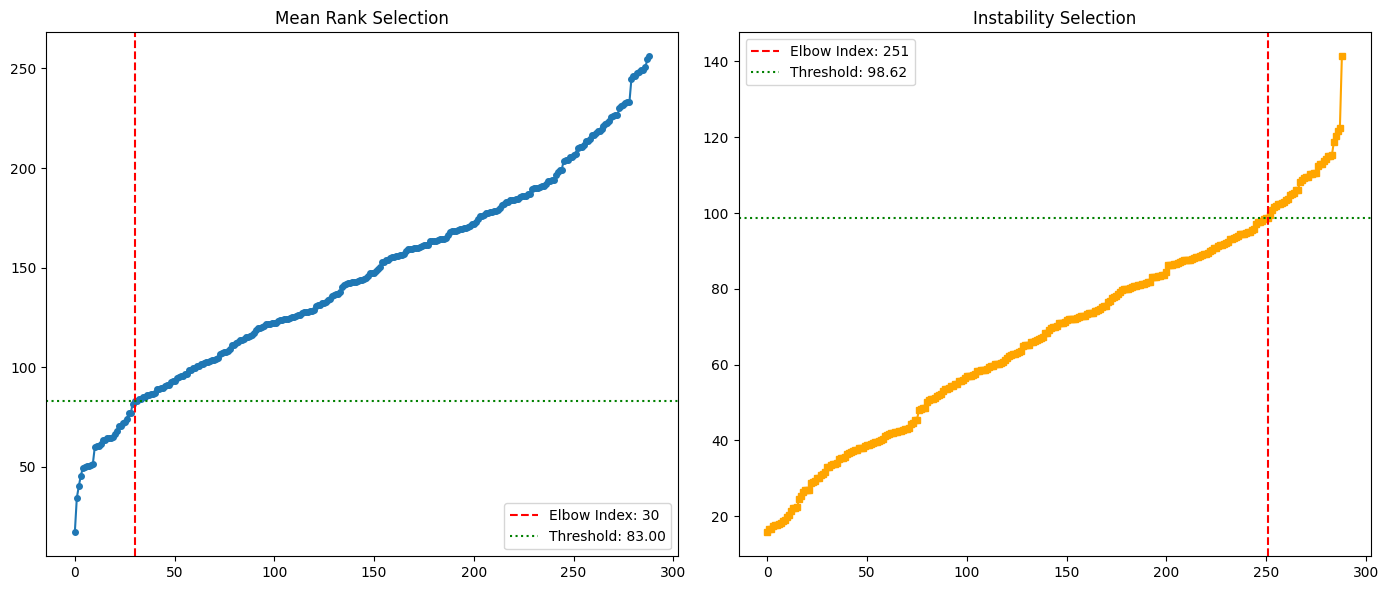

In [ ]:
# Execute on your training data
statistics_ranking = generate_statistical_ranking(X_train, y_train)

# Calculate thresholds
rank_threshold, rank_idx = get_elbow_threshold(statistics_ranking['mean_rank'])
sta_threshold, sta_idx = get_elbow_threshold(statistics_ranking['instability'])

print(f"Recommended Rank Threshold: {rank_threshold:.2f}")
print(f"Recommended Instability Threshold: {sta_threshold:.2f}")

# Plotting the curves
plt.figure(figsize=(14, 6))

# Mean Rank Curve
plt.subplot(1, 2, 1)
plt.plot(np.sort(statistics_ranking['mean_rank']), 'o-', markersize=4)
plt.axvline(x=rank_idx, color='red', linestyle='--', label=f'Elbow Index: {rank_idx}')
plt.axhline(y=rank_threshold, color='green', linestyle=':', label=f'Threshold: {rank_threshold:.2f}')
plt.title('Mean Rank Selection')
plt.legend()

# Instability Curve
plt.subplot(1, 2, 2)
plt.plot(np.sort(statistics_ranking['instability']), 's-', markersize=4, color='orange')
plt.axvline(x=sta_idx, color='red', linestyle='--', label=f'Elbow Index: {sta_idx}')
plt.axhline(y=sta_threshold, color='green', linestyle=':', label=f'Threshold: {sta_threshold:.2f}')
plt.title('Instability Selection')
plt.legend()

plt.tight_layout()
plt.show()

# Fast tunning


In [ ]:
statis_selected_features = statistics_ranking.loc[((statistics_ranking['mean_rank'] <= rank_threshold) & (statistics_ranking['instability'] <= sta_threshold)), :].index.tolist()
statis_selected_features = statis_selected_features + ['regime_0', 'regime_1']

sub_X_train, sub_X_test = X_train.loc[:, statis_selected_features].copy(), X_test.loc[:, statis_selected_features].copy()
print(len(statis_selected_features))
print(statis_selected_features)

34
['volume_nvi', 'volume_adi', 'volume_mfi', 'momentum_tsi', 'volatility_dcw', 'volume_obv', 'trend_adx_pos', 'momentum_wr', 'momentum_roc', 'volume_nvi_lag1_scaled', 'volatility_dch_lag5_scaled', 'trend_dpo_lag1_scaled', 'trend_sma_slow_lag5_scaled', 'volatility_bbli_lag1_momentum', 'momentum_stoch_signal', 'volume_fi', 'momentum_rsi', 'vwap', 'momentum_stoch_rsi_lag1_momentum', 'momentum_stoch', 'momentum_pvo_signal', 'volume_vpt', 'trend_dpo', 'volatility_bbl', 'volatility_dcl', 'trend_visual_ichimoku_b', 'momentum_pvo', 'trend_kst_sig', 'trend_psar_down', 'momentum_ppo', 'trend_aroon_ind', 'trend_visual_ichimoku_a_lag5_momentum', 'regime_0', 'regime_1']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from bayes_opt import BayesianOptimization

# 1. Define the function to maximize
def rf_cv(n_estimators, max_depth, min_samples_leaf, max_samples, max_features):
    """
    Stabilized Objective Function with Feature Control.
    """
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        max_samples=max_samples,
        # max_features is passed as a float (fraction) or int
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Using F1-score to specifically fix the Class 1 precision gap
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, sub_X_train, y_train, cv=tscv, scoring='f1')

    # Target: Reliability (Mean) minus Risk (StdDev)
    return scores.mean() - scores.std()

# 2. Updated "Impossible" Search Space
pbounds = {
    'n_estimators': (150, 400),
    'max_depth': (5, 20),            # Give the trees room to grow and find patterns
    'min_samples_leaf': (10, 50),    # Reduce leaf size to allow for more specific rules
    'max_samples': (0.5, 0.8),
    'max_features': (0.2, 0.6)
}

# 3. Initialize and Optimize
optimizer = BayesianOptimization(
    f=rf_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# init_points: How many steps of random exploration
# n_iter: How many steps of bayesian optimization
optimizer.maximize(init_points=5, n_iter=20)

# 4. Results and Final Model Preparation
print("-" * 30)
print(f"Best Score (F1): {optimizer.max['target']:.4f}")

# Extract best parameters and cast to appropriate types
print(f"Best Parameters: {optimizer.max['params']}")

|   iter    |  target   | n_esti... | max_depth | min_sa... | max_sa... | max_fe... |
-------------------------------------------------------------------------------------
| 1         | 0.5291120 | 243.63502 | 19.260714 | 39.279757 | 0.6795975 | 0.2624074 |
| 2         | 0.4643522 | 188.99863 | 5.8712541 | 44.647045 | 0.6803345 | 0.4832290 |
| 3         | 0.5321319 | 155.14612 | 19.548647 | 43.297705 | 0.5637017 | 0.2727299 |
| 4         | 0.5151301 | 195.85112 | 9.5636336 | 30.990257 | 0.6295835 | 0.3164916 |
| 5         | 0.4663556 | 302.96322 | 7.0924079 | 21.685785 | 0.6099085 | 0.3824279 |
| 6         | 0.5195728 | 301.88621 | 5.0800871 | 41.417801 | 0.6894920 | 0.3802895 |
| 7         | 0.5256402 | 248.84767 | 13.860810 | 21.401351 | 0.6378604 | 0.2809454 |
| 8         | 0.5251102 | 263.96745 | 16.504410 | 30.760248 | 0.5363074 | 0.2313590 |
| 9         | 0.4744740 | 176.77539 | 12.879383 | 16.381687 | 0.7478279 | 0.4973722 |
| 10        | 0.5026269 | 387.25456 | 19.703920 | 34.3


## Model fitting check

In [ ]:
  def train_regime_with_smote(X_combined, y_combined, model):
      """
      Trains and evaluates a combined dataset (with encoded regimes)
      using SMOTE and L1 Logistic Regression inside a strict
      Time Series Cross-Validation loop.
      """
      # 1. Set up the Time Series split (preserves chronological order)
      tscv = TimeSeriesSplit(n_splits=5)

      # 2. Build the Leak-Proof Pipeline
      pipeline = Pipeline([
          # Step A: Scale features (Crucial for SMOTE distance math AND L1 penalty)
          ('scaler', StandardScaler()),

          # Step B: Apply SMOTE (imblearn pipeline ensures this ONLY hits training data)
          ('smote', SMOTE(random_state=42)),

          # Step C: The Classifier (L1 Logistic Regression to aggressively kill noise)
          ('classifier', model)
      ])

      # Tracking metrics across folds
      fold_accuracies = []

      print("Starting Cross-Validation on Combined Dataset...\n")

      # 3. Iterate through the chronological folds
      for fold, (train_idx, test_idx) in enumerate(tscv.split(X_combined)):
          X_train, X_test = X_combined.iloc[train_idx], X_combined.iloc[test_idx]
          y_train, y_test = y_combined.iloc[train_idx], y_combined.iloc[test_idx]

          # Pipeline scales X_train, applies SMOTE, then fits Logistic Regression
          pipeline.fit(X_train, y_train)

          # Predict on pure, unseen test data (NO SMOTE applied here)
          y_pred = pipeline.predict(X_test)

          acc = accuracy_score(y_test, y_pred)
          fold_accuracies.append(acc)

          # Extract the resampled data size to show how much synthetic data was created
          smote_step = pipeline.named_steps['smote']
          X_train_resampled, _ = smote_step.fit_resample(X_train, y_train)

          print(f"Fold {fold+1}:")
          print(f"  -> Original Train Size: {len(X_train)} | Post-SMOTE Size: {len(X_train_resampled)}")
          print(f"  -> Test Size: {len(X_test)} | Accuracy: {acc:.4f}\n")

      # --- Final Evaluation ---
      print("--- Final CV Results ---")
      print(f"Mean CV Accuracy: {np.mean(fold_accuracies):.4f}")

      # 4. Train final model on the ENTIRE combined dataset
      final_model = pipeline.fit(X_combined, y_combined)

      return final_model

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
params = optimizer.max['params']

best_params_1 = {
    'n_estimators': int(params['n_estimators']),
    'max_depth': int(params['max_depth']),
    'min_samples_leaf': int(params['min_samples_leaf']), # Switched to leaf for stability
    'max_samples': params['max_samples'],                # Fraction of data per tree
    'max_features': params['max_features'],              # Fraction of features per tree
    'class_weight': 'balanced',                          # Fixes the Class 1 precision gap
    'random_state': 42,
    'n_jobs': -1
}

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
print(f"Best Parameters: {best_params_1}")

# 2. Initialize and fit the best model
# Using the optimized parameters found during the search
best_rf_model = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params_1))

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(best_rf_model, sub_X_train, y_train, cv=tscv, scoring='accuracy')

print("--- Cross-Validation (CV) Test Results ---")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Stability (Std Dev): {np.std(cv_scores):.4f}")
print(f"Individual Fold Scores: {cv_scores}")
print("-" * 45)

# 3. Predict on the test set
# Ensure you use 'sub_X_test' to match the 'sub_X_train' used in training
y_pred_tuned = best_rf_model.predict(sub_X_test)

# 4. Results
print("\n--- Tuned Random Forest Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("-" * 45)
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'n_estimators': 155, 'max_depth': 19, 'min_samples_leaf': 43, 'max_samples': np.float64(0.5637017332034828), 'max_features': np.float64(0.2727299868828402), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Starting Cross-Validation on Combined Dataset...

Fold 1:
  -> Original Train Size: 296 | Post-SMOTE Size: 304
  -> Test Size: 291 | Accuracy: 0.5052

Fold 2:
  -> Original Train Size: 587 | Post-SMOTE Size: 612
  -> Test Size: 291 | Accuracy: 0.4536

Fold 3:
  -> Original Train Size: 878 | Post-SMOTE Size: 896
  -> Test Size: 291 | Accuracy: 0.5223

Fold 4:
  -> Original Train Size: 1169 | Post-SMOTE Size: 1270
  -> Test Size: 291 | Accuracy: 0.5017

Fold 5:
  -> Original Train Size: 1460 | Post-SMOTE Size: 1606
  -> Test Size: 291 | Accuracy: 0.5395

--- Final CV Results ---
Mean CV Accuracy: 0.5045
--- Cross-Validation (CV) Test Results ---
Mean CV Accuracy: 0.5045
CV Stability (Std Dev): 0.0288
Individual Fold Scores: [0.50515464 0.45360825 0.522336

# Diagnosis

## Learning Curve

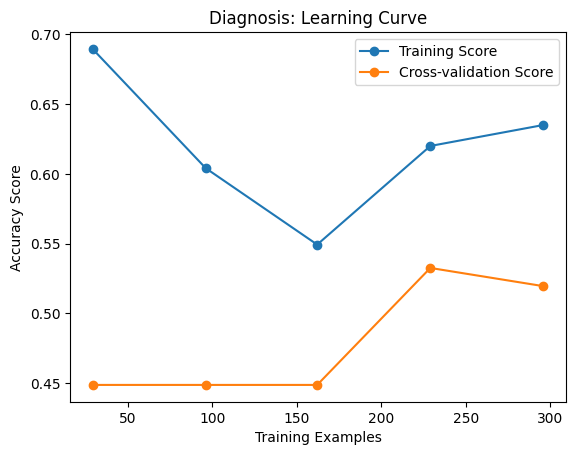

In [ ]:
from sklearn.model_selection import learning_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# --- 1. Learning Curve Diagnosis ---
def plot_learning_curve(model, X, y):

    tscv = TimeSeriesSplit(n_splits=5)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=tscv, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score")
    plt.title("Diagnosis: Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend()
    plt.show()

# Execution
rf = RandomForestClassifier(**best_params_1)
plot_learning_curve(rf, sub_X_train, y_train)

## Calibration Diagnostic

In [ ]:
import pandas as pd

# 1. Get the probabilities
rf = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params_1))
y_prob = rf.predict_proba(sub_X_test)[:, 1]

# 2. Create a DataFrame for analysis
results = pd.DataFrame({
    'actual': y_test,
    'prob': y_prob
})

# 3. Define confidence tiers
def check_precision(df, low, high):
    subset = df[(df['prob'] >= low) & (df['prob'] < high)]
    if len(subset) == 0: return 0, 0
    precision = subset['actual'].mean()
    return precision, len(subset)

# Diagnostic Printout
print("Confidence Tier | Precision (Accuracy) | Sample Count")
print("-" * 50)
for low, high in [(0, 0.35), (0.35, 0.45), (0.45, 0.55), (0.55, 0.65), (0.65, 1.0)]:
    prec, count = check_precision(results, low, high)
    # For low tiers, 'precision' is actually the accuracy of predicting Class 0
    if low < 0.45:
        display_prec = 1 - prec
        label = "Class 0"
    else:
        display_prec = prec
        label = "Class 1"
    print(f"{low:.2f} - {high:.2f}   | {display_prec:.2%} - {label}       | {count}")

Starting Cross-Validation on Combined Dataset...

Fold 1:
  -> Original Train Size: 296 | Post-SMOTE Size: 304
  -> Test Size: 291 | Accuracy: 0.5052

Fold 2:
  -> Original Train Size: 587 | Post-SMOTE Size: 612
  -> Test Size: 291 | Accuracy: 0.4536

Fold 3:
  -> Original Train Size: 878 | Post-SMOTE Size: 896
  -> Test Size: 291 | Accuracy: 0.5223

Fold 4:
  -> Original Train Size: 1169 | Post-SMOTE Size: 1270
  -> Test Size: 291 | Accuracy: 0.5017

Fold 5:
  -> Original Train Size: 1460 | Post-SMOTE Size: 1606
  -> Test Size: 291 | Accuracy: 0.5395

--- Final CV Results ---
Mean CV Accuracy: 0.5045
Confidence Tier | Precision (Accuracy) | Sample Count
--------------------------------------------------
0.00 - 0.35   | 100.00% - Class 0       | 0
0.35 - 0.45   | 48.18% - Class 0       | 137
0.45 - 0.55   | 46.19% - Class 1       | 236
0.55 - 0.65   | 60.00% - Class 1       | 50
0.65 - 1.00   | 0.00% - Class 1       | 0


# Model-Oriented Feature Selection:

In [ ]:
import pandas as pd
import numpy as np
from boruta import BorutaPy
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline # Import Pipeline from imblearn

def optimize_rf_selectors(X, y, rf_params):
    """
    Evaluates features based on absolute survival (Boruta) and absolute F1 impact (Permutation).
    """
    tscv = TimeSeriesSplit(n_splits=5)

    # DataFrames to store raw fold results
    boruta_hits = pd.DataFrame(index=X.columns)
    perm_impacts = pd.DataFrame(index=X.columns)

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_test_fold, y_test_fold = X.iloc[test_idx], y.iloc[test_idx]

        # Instantiate a RandomForestClassifier for Boruta
        # Boruta needs direct access to the n_estimators parameter
        rf_boruta = RandomForestClassifier(**rf_params)

        # --- Method 1: Boruta (The Gatekeeper) ---
        # Boruta requires numpy arrays (.values)
        boruta_selector = BorutaPy(rf_boruta, n_estimators='auto', verbose=0, random_state=42)
        boruta_selector.fit(X_train_fold.values, y_train_fold.values)

        # Record 1 if Boruta CONFIRMED the feature, 0 otherwise
        boruta_hits[f'Fold_{i}'] = (boruta_selector.ranking_ == 1).astype(int)

        # --- Method 2: Permutation Importance (The Ranker) ---
        # Create a pipeline for permutation importance, including scaler and SMOTE
        # This pipeline will be fitted and used for permutation_importance
        pipeline_perm_imp = Pipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(**rf_params))
        ])

        pipeline_perm_imp.fit(X_train_fold, y_train_fold)

        # Permute on the UNSEEN test fold, scoring strictly on F1
        perm_result = permutation_importance(
            pipeline_perm_imp, X_test_fold, y_test_fold, n_repeats=5, scoring='f1_macro', n_jobs=-1, random_state=42
        )
        perm_impacts[f'Fold_{i}'] = perm_result.importances_mean

    # --- Aggregation ---
    final_eval = pd.DataFrame(index=X.columns)

    # 1. Boruta Hit Rate: % of time-folds where feature beat random noise
    final_eval['boruta_hit_rate'] = boruta_hits.mean(axis=1)

    # 2. Permutation Net Benefit: Average F1 drop when feature is removed
    final_eval['mean_f1_impact'] = perm_impacts.mean(axis=1)

    # 3. Permutation Stability: Standard deviation of F1 impact
    final_eval['f1_impact_std'] = perm_impacts.std(axis=1)

    return final_eval

# --- 1. Execute on Phase 1 Features ---
# Use the features that survived your statistical Elbow method
# Pass 'best_params_1' directly, not a fitted pipeline
phase_2_eval = optimize_rf_selectors(X_train[statis_selected_features], y_train, rf_params=best_params_1)
phase_2_eval

,boruta_hit_rate,mean_f1_impact,f1_impact_std
volume_nvi,0.0,-0.000772,0.006391
volume_adi,0.0,0.004155,0.004776
volume_mfi,0.0,-0.005931,0.020697
momentum_tsi,0.0,-0.011410,0.010152
volatility_dcw,0.0,-0.007069,0.006002
volume_obv,0.2,-0.003182,0.007115
trend_adx_pos,0.0,-0.006867,0.007997
momentum_wr,0.0,-0.003891,0.010572
momentum_roc,0.0,-0.007136,0.008139
volume_nvi_lag1_scaled,0.0,0.007017,0.023604


In [ ]:
# --- 2. THE ABSOLUTE LOGIC FILTER ---
# Rule 1: The feature must actively improve the F1 score (impact > 0).
#         If impact is <= 0, the model is better off or unchanged without it.
# Rule 2: It must survive Boruta in at least 2 out of 5 folds (>= 0.4 hit rate) to prove time-stability.

logit_selected_features = phase_2_eval[ ((phase_2_eval['mean_f1_impact'] + phase_2_eval['f1_impact_std']) > 0) & (phase_2_eval['boruta_hit_rate'] >= 0.4) ].sort_values(by='mean_f1_impact', ascending=False).index.tolist()
if not logit_selected_features:
    logit_selected_features = phase_2_eval[ ((phase_2_eval['mean_f1_impact'] + phase_2_eval['f1_impact_std']) > 0) | (phase_2_eval['boruta_hit_rate'] >= 0.4) ].sort_values(by='mean_f1_impact', ascending=False).index.tolist()

print(f"Features surviving absolute logic filter: {len(logit_selected_features)}")
display(phase_2_eval.loc[logit_selected_features])

Features surviving absolute logic filter: 28


,boruta_hit_rate,mean_f1_impact,f1_impact_std
trend_dpo,0.0,0.013192,0.024530
volume_nvi_lag1_scaled,0.0,0.007017,0.023604
volume_adi,0.0,0.004155,0.004776
momentum_rsi,0.0,0.001863,0.010127
trend_kst_sig,0.0,0.001814,0.010651
trend_dpo_lag1_scaled,0.0,0.000635,0.014043
vwap,0.0,0.000555,0.001241
volume_vpt,0.0,0.000385,0.007047
regime_0,0.0,0.000260,0.000582
regime_1,0.0,0.000260,0.000581


# Hyper-parameter Tuning

In [ ]:
logit_selected_features = logit_selected_features + ['regime_0', 'regime_1']

sub_X_train, sub_X_test = X_train.loc[:, logit_selected_features].copy(), X_test.loc[:, logit_selected_features].copy()
print(len(logit_selected_features))
print(logit_selected_features)

30
['trend_dpo', 'volume_nvi_lag1_scaled', 'volume_adi', 'momentum_rsi', 'trend_kst_sig', 'trend_dpo_lag1_scaled', 'vwap', 'volume_vpt', 'regime_0', 'regime_1', 'trend_psar_down', 'trend_aroon_ind', 'volatility_dcl', 'volume_nvi', 'volatility_bbl', 'momentum_stoch_rsi_lag1_momentum', 'trend_visual_ichimoku_b', 'momentum_stoch', 'trend_visual_ichimoku_a_lag5_momentum', 'volume_obv', 'momentum_wr', 'volume_fi', 'volume_mfi', 'trend_adx_pos', 'momentum_ppo', 'momentum_roc', 'momentum_stoch_signal', 'trend_sma_slow_lag5_scaled', 'regime_0', 'regime_1']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np

# 1. Define the function to maximize
def rf_cv(n_estimators, max_depth, min_samples_leaf, max_samples, max_features):
    """
    Stabilized Objective Function with Feature Control.
    """
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        max_samples=max_samples,
        # max_features is passed as a float (fraction) or int
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Using F1-score to specifically fix the Class 1 precision gap
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, sub_X_train, y_train, cv=tscv, scoring='f1')

    # Target: Reliability (Mean) minus Risk (StdDev)
    return scores.mean() - scores.std()

# 2. Updated "Impossible" Search Space
pbounds = {
    'n_estimators': (150, 300),
    'max_depth': (3, 6),             # Even tighter constraint
    'min_samples_leaf': (60, 150),   # Very large leaves for maximum globality
    'max_samples': (0.5, 0.7),       # Heavy subsampling
    'max_features': (0.1, 0.5)       # Only allow trees to see 10% - 50% of features
}

# 3. Initialize and Optimize
optimizer = BayesianOptimization(
    f=rf_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# init_points: How many steps of random exploration
# n_iter: How many steps of bayesian optimization
optimizer.maximize(init_points=5, n_iter=20)

# 4. Results and Final Model Preparation
print("-" * 30)
print(f"Best Score (F1): {optimizer.max['target']:.4f}")

# Extract best parameters and cast to appropriate types
print(f"Best Parameters: {optimizer.max['params']}")

|   iter    |  target   | n_esti... | max_depth | min_sa... | max_sa... | max_fe... |
-------------------------------------------------------------------------------------
| 1         | 0.2282565 | 206.18101 | 5.8521429 | 125.87945 | 0.6197316 | 0.1624074 |
| 2         | 0.1758217 | 173.39917 | 3.1742508 | 137.95585 | 0.6202230 | 0.3832290 |
| 3         | 0.0561013 | 153.08767 | 5.9097295 | 134.91983 | 0.5424678 | 0.1727299 |
| 4         | 0.2051295 | 177.51067 | 3.9127267 | 107.22807 | 0.5863890 | 0.2164916 |
| 5         | 0.1972400 | 241.77793 | 3.4184815 | 86.293018 | 0.5732723 | 0.2824279 |
| 6         | 0.1994164 | 207.29343 | 5.1536697 | 126.22502 | 0.5938877 | 0.3326362 |
| 7         | 0.2284451 | 202.24046 | 6.0       | 124.65777 | 0.7       | 0.1       |
| 8         | 0.2259315 | 205.55385 | 6.0       | 119.96484 | 0.6932309 | 0.1       |
| 9         | 0.2321007 | 201.69185 | 6.0       | 131.51825 | 0.7       | 0.1       |
| 10        | 0.0643006 | 194.48640 | 6.0       | 131.


## Model fitting check

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
params = optimizer.max['params']
#params['max_features'] = 'sqrt'

best_params = {
    'n_estimators': int(params['n_estimators']),
    'max_depth': int(params['max_depth']),
    'min_samples_leaf': int(params['min_samples_leaf']),  # Switched to leaf for stability
    'max_samples': params['max_samples'],                # Fraction of data per tree
    'max_features': params['max_features'],               # Fraction of features per tree
    'class_weight': 'balanced',                          # Fixes the Class 1 precision gap
    'random_state': 42,
    'n_jobs': -1
}
print(f"Best Parameters: {best_params}")

# 2. Initialize and fit the best model
# Using the optimized parameters found during the search
best_rf_model = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params))

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(best_rf_model, sub_X_train, y_train, cv=tscv, scoring='accuracy')

print("--- Cross-Validation (CV) Test Results ---")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Stability (Std Dev): {np.std(cv_scores):.4f}")
print(f"Individual Fold Scores: {cv_scores}")
print("-" * 45)

# 3. Predict on the test set
# Ensure you use 'sub_X_test' to match the 'sub_X_train' used in training
best_rf_model = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params))
y_pred_tuned = best_rf_model.predict(sub_X_test)

# 4. Results
print("\n--- Tuned Random Forest Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("-" * 45)
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'n_estimators': 211, 'max_depth': 6, 'min_samples_leaf': 141, 'max_samples': np.float64(0.7), 'max_features': np.float64(0.1), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Starting Cross-Validation on Combined Dataset...

Fold 1:
  -> Original Train Size: 296 | Post-SMOTE Size: 304
  -> Test Size: 291 | Accuracy: 0.4433

Fold 2:
  -> Original Train Size: 587 | Post-SMOTE Size: 612
  -> Test Size: 291 | Accuracy: 0.4605

Fold 3:
  -> Original Train Size: 878 | Post-SMOTE Size: 896
  -> Test Size: 291 | Accuracy: 0.5395

Fold 4:
  -> Original Train Size: 1169 | Post-SMOTE Size: 1270
  -> Test Size: 291 | Accuracy: 0.5533

Fold 5:
  -> Original Train Size: 1460 | Post-SMOTE Size: 1606
  -> Test Size: 291 | Accuracy: 0.5601

--- Final CV Results ---
Mean CV Accuracy: 0.5113
--- Cross-Validation (CV) Test Results ---
Mean CV Accuracy: 0.5113
CV Stability (Std Dev): 0.0493
Individual Fold Scores: [0.44329897 0.4604811  0.5395189  0.5532646  0.56013746]
----

# Threshold Optimize

## Plots


--- Model Performance at 0.5 Threshold ---
Accuracy: 0.5035
              precision    recall  f1-score   support

           0       0.50      0.80      0.62       213
           1       0.50      0.20      0.29       210

    accuracy                           0.50       423
   macro avg       0.50      0.50      0.45       423
weighted avg       0.50      0.50      0.45       423



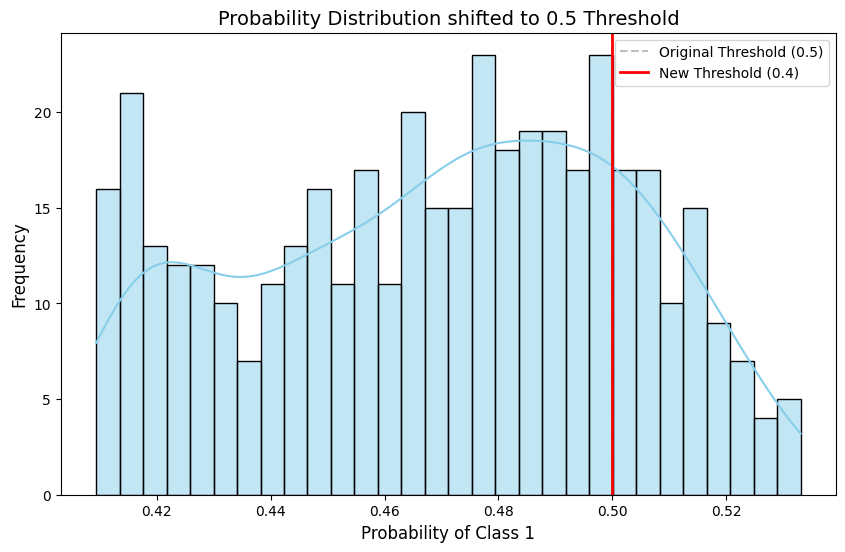

In [ ]:
# 1. Get probabilities for the positive class
y_probs = best_rf_model.predict_proba(sub_X_test)[:, 1]

# 2. Apply the standard 50% threshold
threshold = 0.5
y_pred_04 = (y_probs >= threshold).astype(int)

# 3. Evaluate Performance
print(f"\n--- Model Performance at {threshold} Threshold ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_04):.4f}")
print(classification_report(y_test, y_pred_04))

# 4. Plot the Distribution with the new threshold
plt.figure(figsize=(10, 6))
sns.histplot(y_probs, bins=30, kde=True, color='skyblue', edgecolor='black')

# Visualizing the shift
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Original Threshold (0.5)')
plt.axvline(x=threshold, color='red', linestyle='-', linewidth=2, label='New Threshold (0.4)')

plt.title(f'Probability Distribution shifted to {threshold} Threshold', fontsize=14)
plt.xlabel('Probability of Class 1', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

## Model fitting check with manual threshold setiting

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_probs):
    """
    Finds the optimal threshold by maximizing the F1-score.

    y_true: Ground truth labels (0 or 1)
    y_probs: Predicted probabilities for the positive class
    """
    # Calculate precision and recall for all possible thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)

    # Calculate F1-score for each threshold
    # F1 = 2 * (precision * recall) / (precision + recall)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

    # Get the index of the highest F1 score
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, f1_scores[best_idx]

# Example usage:
y_probs = best_rf_model.predict_proba(sub_X_test)[:, 1]
best_thresh, best_f1 = find_best_threshold(y_test, y_probs)
print(f"Optimal Threshold: {best_thresh:.4f} with F1-Score: {best_f1:.4f}")

# 3. Final Fit and Evaluation (The "Performance" Check)
y_pred = (y_probs >= best_thresh).astype(int)

print("\n--- Final Test Set Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Optimal Threshold: 0.4094 with F1-Score: 0.6635

--- Final Test Set Performance ---
Accuracy: 0.4965
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       213
           1       0.50      1.00      0.66       210

    accuracy                           0.50       423
   macro avg       0.25      0.50      0.33       423
weighted avg       0.25      0.50      0.33       423



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Diagnosis

## Learning Curve

Starting Cross-Validation on Combined Dataset...

Fold 1:
  -> Original Train Size: 296 | Post-SMOTE Size: 304
  -> Test Size: 291 | Accuracy: 0.4433

Fold 2:
  -> Original Train Size: 587 | Post-SMOTE Size: 612
  -> Test Size: 291 | Accuracy: 0.4605

Fold 3:
  -> Original Train Size: 878 | Post-SMOTE Size: 896
  -> Test Size: 291 | Accuracy: 0.5395

Fold 4:
  -> Original Train Size: 1169 | Post-SMOTE Size: 1270
  -> Test Size: 291 | Accuracy: 0.5533

Fold 5:
  -> Original Train Size: 1460 | Post-SMOTE Size: 1606
  -> Test Size: 291 | Accuracy: 0.5601

--- Final CV Results ---
Mean CV Accuracy: 0.5113


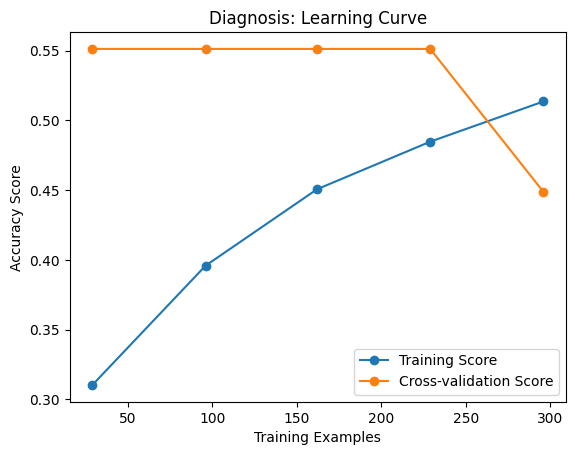

In [ ]:
# Execution
best_rf_model = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params))
plot_learning_curve(best_rf_model, sub_X_train, y_train)

## Calibration Diagnostic

In [ ]:
import pandas as pd

# 1. Get the probabilities
best_rf_model = train_regime_with_smote(sub_X_train, y_train, model=RandomForestClassifier(**best_params))
y_prob = best_rf_model.predict_proba(sub_X_test)[:, 1]

# 2. Create a DataFrame for analysis
results = pd.DataFrame({
    'actual': y_test,
    'prob': y_prob
})

# 3. Define confidence tiers
def check_precision(df, low, high):
    subset = df[(df['prob'] >= low) & (df['prob'] < high)]
    if len(subset) == 0: return 0, 0
    precision = subset['actual'].mean()
    return precision, len(subset)

# Diagnostic Printout
print("Confidence Tier | Precision (Accuracy) | Sample Count")
print("-" * 50)
for low, high in [(0, 0.35), (0.35, 0.45), (0.45, 0.55), (0.55, 0.65), (0.65, 1.0)]:
    prec, count = check_precision(results, low, high)
    # For low tiers, 'precision' is actually the accuracy of predicting Class 0
    if low < 0.45:
        display_prec = 1 - prec
        label = "Class 0"
    else:
        display_prec = prec
        label = "Class 1"
    print(f"{low:.2f} - {high:.2f}   | {display_prec:.2%}- {label}       | {count}")

Starting Cross-Validation on Combined Dataset...

Fold 1:
  -> Original Train Size: 296 | Post-SMOTE Size: 304
  -> Test Size: 291 | Accuracy: 0.4433

Fold 2:
  -> Original Train Size: 587 | Post-SMOTE Size: 612
  -> Test Size: 291 | Accuracy: 0.4605

Fold 3:
  -> Original Train Size: 878 | Post-SMOTE Size: 896
  -> Test Size: 291 | Accuracy: 0.5395

Fold 4:
  -> Original Train Size: 1169 | Post-SMOTE Size: 1270
  -> Test Size: 291 | Accuracy: 0.5533

Fold 5:
  -> Original Train Size: 1460 | Post-SMOTE Size: 1606
  -> Test Size: 291 | Accuracy: 0.5601

--- Final CV Results ---
Mean CV Accuracy: 0.5113
Confidence Tier | Precision (Accuracy) | Sample Count
--------------------------------------------------
0.00 - 0.35   | 100.00%- Class 0       | 0
0.35 - 0.45   | 45.38%- Class 0       | 130
0.45 - 0.55   | 47.44%- Class 1       | 293
0.55 - 0.65   | 0.00%- Class 1       | 0
0.65 - 1.00   | 0.00%- Class 1       | 0
